# Classificação de Recortes Mamográficos com CNN

Este notebook organiza um fluxo de classificação de recortes mamográficos com uma Rede Neural Convolucional. O objetivo é distinguir se o achado presente no recorte está associado a um caso benigno ou maligno, de acordo com os rótulos presentes na base.


## 1. Bibliotecas utilizadas

As bibliotecas abaixo cobrem leitura dos arquivos, visualização, preparação das imagens, construção da CNN e avaliação do classificador.


In [1]:
from pathlib import Path  # Facilita a manipulação dos caminhos dos arquivos.

import matplotlib.pyplot as plt  # Gera gráficos para análise da base e do treinamento.
import pandas as pd  # Organiza os caminhos e rótulos em DataFrames.
import seaborn as sns  # Produz visualizações estatísticas mais legíveis.
import tensorflow as tf  # Biblioteca principal para construir e treinar a CNN.

from PIL import Image  # Abre amostras de imagem para inspeção visual.
from sklearn.metrics import classification_report, confusion_matrix  # Resume o desempenho final do classificador.
from sklearn.model_selection import train_test_split  # Cria a separação entre treino e validação.
from tensorflow import keras  # Interface de alto nível do TensorFlow.
from tensorflow.keras import layers  # Reúne as camadas usadas na arquitetura.

sns.set_theme(style='whitegrid')  # Padroniza o estilo visual dos gráficos.
plt.rcParams['figure.figsize'] = (10, 6)  # Define um tamanho padrão para as figuras.
pd.set_option('display.max_columns', None)  # Evita ocultar colunas relevantes nas tabelas.

SEED = 42
keras.utils.set_random_seed(SEED)  # Mantém a execução mais reprodutível.

print('TensorFlow:', tf.__version__)


TensorFlow: 2.19.0


## 2. Estrutura da base utilizada

O dataset foi obtido através da plataforma Kaggle, que já disponibiliza imagens em formato JPEG e traz os recortes associados aos achados classificados. Para este projeto, foi criada a pasta `cnn_dataset` para armazenar os dados, a qual foi reorganizada para manter apenas os recortes efetivamente utilizados, distribuídos em quatro diretórios:

- `train/BENIGN`
- `train/MALIGNANT`
- `test/BENIGN`
- `test/MALIGNANT`

Com isso, o notebook não precisa reconstruir exames completos nem localizar manualmente as regiões de interesse. O trabalho de pré-processamento que já vinha da base foi aproveitado, e a etapa local ficou restrita à leitura, padronização e preparação dos recortes para o modelo.


## 3. Leitura dos recortes classificados

O primeiro passo é montar uma tabela simples com o caminho de cada imagem, a partição a que ela pertence (`train` ou `test`) e o respectivo rótulo (`BENIGN` ou `MALIGNANT`).


In [2]:
dataset_root = Path('dataset/cnn_dataset')


def montar_dataframe(split):
    registros = []
    # Cada subpasta representa uma classe dentro da partição informada.
    for classe_dir in sorted((dataset_root / split).iterdir()):
        if not classe_dir.is_dir():
            continue
        for image_path in sorted(classe_dir.glob('*.jpg')):
            registros.append(
                {
                    'split': split,
                    'label_name': classe_dir.name,
                    'image_path': image_path,
                }
            )
    df_split = pd.DataFrame(registros)
    df_split['label_encoded'] = df_split['label_name'].map({'BENIGN': 0, 'MALIGNANT': 1})  # Converte a classe para o formato bin?rio usado pela rede.
    return df_split


train_df = montar_dataframe('train')
test_df = montar_dataframe('test')
df_images = pd.concat([train_df, test_df], ignore_index=True)

print('Treino:', train_df.shape)
print('Teste :', test_df.shape)
display(df_images.head())


Treino: (2863, 4)
Teste : (704, 4)


,split,label_name,image_path,label_encoded
0,train,BENIGN,dataset\cnn_dataset\train\BENIGN\Calc-Training...,0
1,train,BENIGN,dataset\cnn_dataset\train\BENIGN\Calc-Training...,0
2,train,BENIGN,dataset\cnn_dataset\train\BENIGN\Calc-Training...,0
3,train,BENIGN,dataset\cnn_dataset\train\BENIGN\Calc-Training...,0
4,train,BENIGN,dataset\cnn_dataset\train\BENIGN\Calc-Training...,0


Como a base já está organizada por classe, esta etapa fica bastante direta. O principal ajuste adicional é apenas transformar o rótulo textual em formato numérico, para que ele possa ser usado no treinamento do modelo.


In [3]:
resumo_base = pd.DataFrame(
    {
        'linhas_totais': [len(df_images)],
        'imagens_unicas': [df_images['image_path'].nunique()],
        'treino': [len(train_df)],
        'teste': [len(test_df)],
    }
)

display(resumo_base)
display(df_images.groupby(['split', 'label_name']).size().rename('quantidade').reset_index())


,linhas_totais,imagens_unicas,treino,teste
0,3567,3567,2863,704


,split,label_name,quantidade
0,test,BENIGN,428
1,test,MALIGNANT,276
2,train,BENIGN,1682
3,train,MALIGNANT,1181


## 4. Distribuição das classes e inspeção visual

Antes de preparar a CNN, vale observar a distribuição entre benignos e malignos e inspecionar alguns recortes. Isso ajuda a contextualizar o conjunto de dados e a natureza da entrada que será fornecida ao modelo.


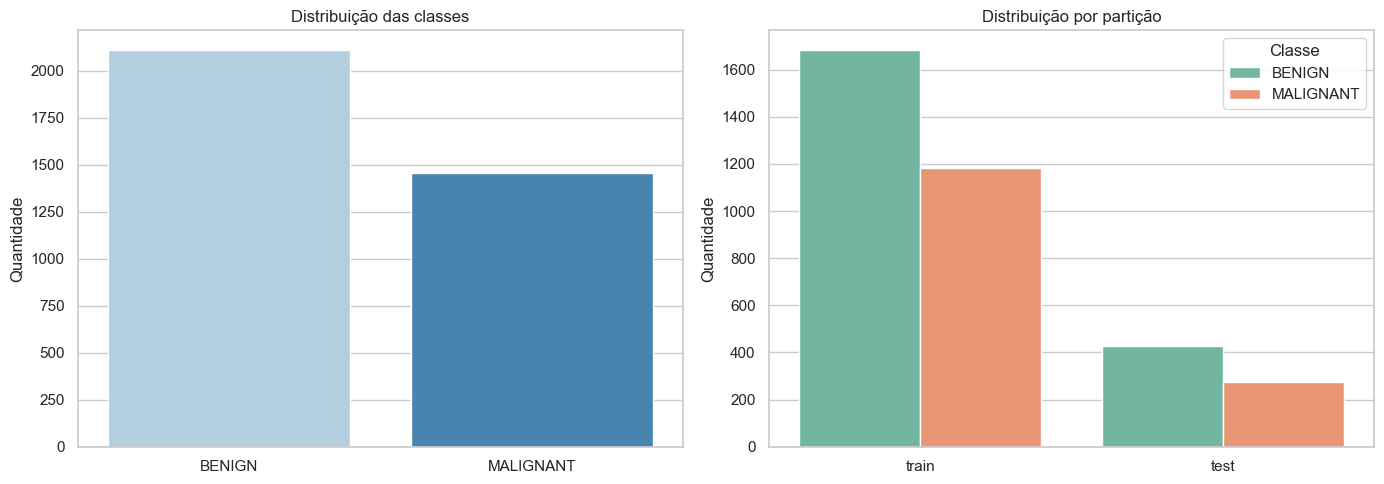

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Mostra o volume total de imagens por classe.
sns.countplot(data=df_images, x='label_name', hue='label_name', palette='Blues', legend=False, ax=axes[0])
axes[0].set_title('Distribuição das classes')
axes[0].set_xlabel('')
axes[0].set_ylabel('Quantidade')

# Compara a distribuição entre treino e teste para verificar se a base permaneceu consistente.
sns.countplot(data=df_images, x='split', hue='label_name', palette='Set2', ax=axes[1])
axes[1].set_title('Distribuição por partição')
axes[1].set_xlabel('')
axes[1].set_ylabel('Quantidade')
axes[1].legend(title='Classe')

plt.tight_layout()
plt.show()


A distribuição entre as classes não é perfeitamente uniforme, mas permanece adequada para um experimento supervisionado dessa escala. Ainda assim, o comportamento da classe maligna merece atenção especial na avaliação, por representar a classe positiva do problema.


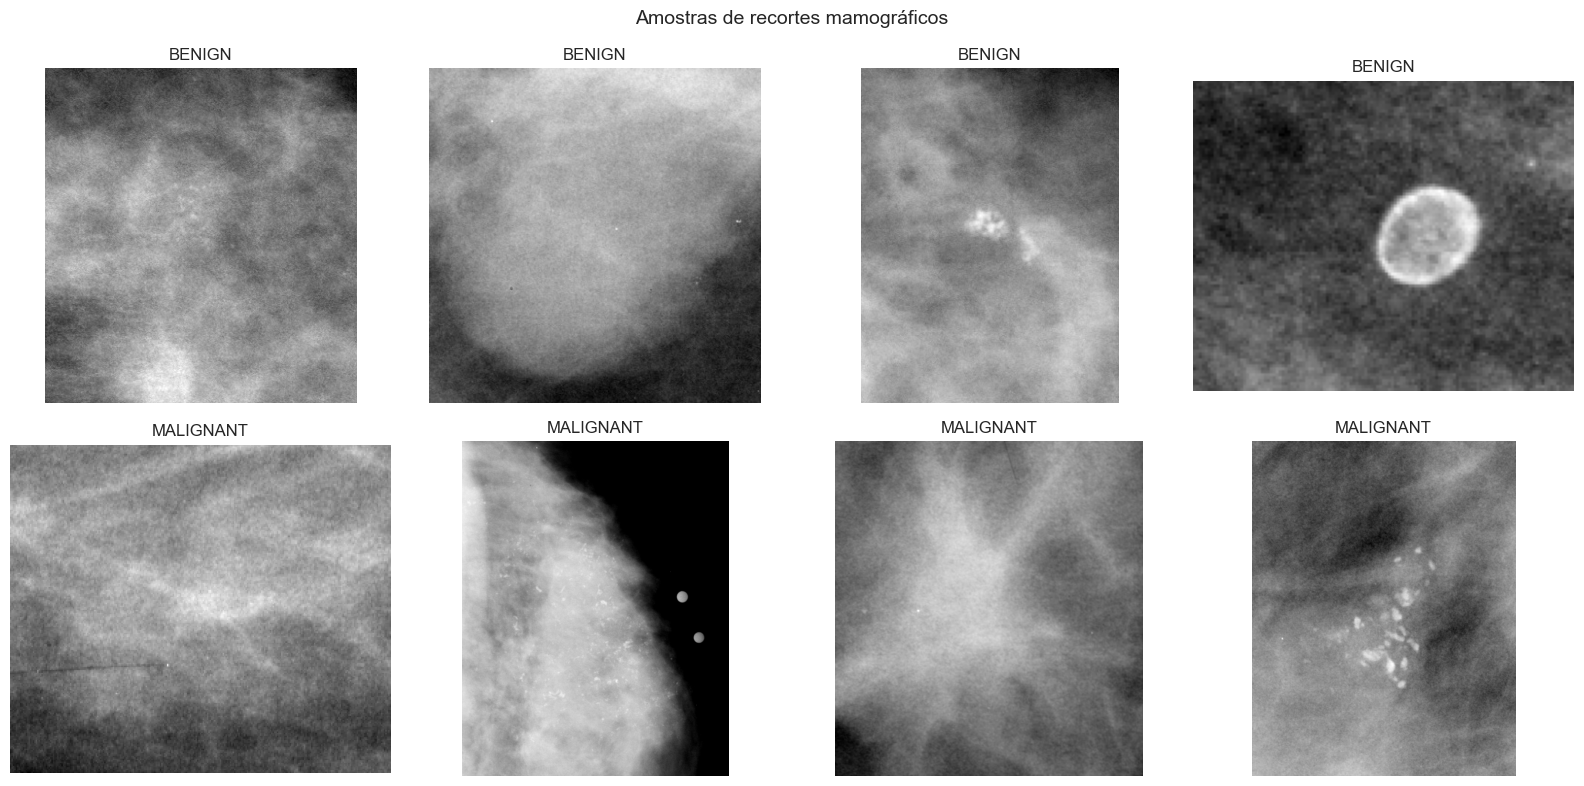

In [5]:
amostras = (
    df_images.groupby('label_name', group_keys=False)
    .sample(n=4, random_state=SEED)  # Seleciona exemplos de cada classe para inspeção visual equilibrada.
    .reset_index(drop=True)
)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for ax, (_, row) in zip(axes.flatten(), amostras.iterrows()):
    with Image.open(row['image_path']) as img:
        ax.imshow(img, cmap='gray')
    ax.set_title(row['label_name'])
    ax.axis('off')

plt.suptitle('Amostras de recortes mamográficos', fontsize=14)
plt.tight_layout()
plt.show()


## 5. Separação entre treino, validação e teste

O conjunto de teste já está previamente separado na base simplificada. A partir do conjunto de treino, será criada uma partição de validação para acompanhar o aprendizado da rede sem usar o teste durante o ajuste dos pesos.


In [6]:
train_split_df, val_df = train_test_split(
    train_df,
    test_size=0.20,
    stratify=train_df['label_encoded'],  # Preserva a proporção entre benignos e malignos na validação.
    random_state=SEED,
)

resumo_particoes = pd.DataFrame(
    [
        {'conjunto': 'Treino', 'linhas': len(train_split_df), 'proporcao_malignos': train_split_df['label_encoded'].mean()},
        {'conjunto': 'Validação', 'linhas': len(val_df), 'proporcao_malignos': val_df['label_encoded'].mean()},
        {'conjunto': 'Teste', 'linhas': len(test_df), 'proporcao_malignos': test_df['label_encoded'].mean()},
    ]
)

display(resumo_particoes)


,conjunto,linhas,proporcao_malignos
0,Treino,2290,0.412664
1,Validação,573,0.411867
2,Teste,704,0.392045


O uso de `stratify` ajuda a preservar a proporção entre benignos e malignos nas três partições. Isso reduz o risco de comparar conjuntos com distribuições muito diferentes entre si.


## 6. Pré-processamento final das imagens

Como a base já fornece os recortes em JPEG e com rótulos definidos, o pré-processamento local se concentra apenas em etapas finais de preparação:

- leitura do arquivo;
- conversão para tensor;
- redimensionamento;
- normalização dos pixels;
- organização em lotes.


In [7]:
IMAGE_SIZE = (96, 96)
BATCH_SIZE = 32
EPOCHS = 8  # Número moderado de épocas para manter o treino viável em ambiente local.
AUTOTUNE = tf.data.AUTOTUNE


@tf.autograph.experimental.do_not_convert
def decode_image(path, label):
    image = tf.io.read_file(path)  # Lê o arquivo de imagem a partir do caminho armazenado no DataFrame.
    image = tf.image.decode_jpeg(image, channels=1)  # Decodifica o JPEG em escala de cinza.
    image = tf.image.resize(image, IMAGE_SIZE)  # Padroniza o tamanho de entrada dos recortes.
    image = tf.cast(image, tf.float32) / 255.0  # Ajusta os pixels para a faixa entre 0 e 1.
    return image, tf.cast(label, tf.float32)  # Retorna a imagem preparada e o rótulo no tipo esperado pela modelo.


def make_dataset(df, training=False):
    paths = df['image_path'].astype(str).to_numpy()  # Reúne os caminhos dos arquivos a serem lidos.
    labels = df['label_encoded'].astype('float32').to_numpy()  # Reúne os rótulos binários de cada imagem.

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))  # Pareia cada caminho com seu respectivo rótulo.
    if training:
        ds = ds.shuffle(len(df), seed=SEED, reshuffle_each_iteration=True)  # Embaralha apenas o conjunto de treino.

    ds = ds.map(decode_image, num_parallel_calls=AUTOTUNE)  # Aplica a leitura e o pré-processamento imagem a imagem.
    ds = ds.batch(BATCH_SIZE)  # Organiza as imagens em lotes para o treinamento.
    ds = ds.prefetch(AUTOTUNE)  # Prepara os próximos lotes enquanto o modelo processa o lote atual.
    return ds


train_ds = make_dataset(train_split_df, training=True)
val_ds = make_dataset(val_df)
test_ds = make_dataset(test_df)

for images, labels in train_ds.take(1):
    print('Shape do lote de imagens:', images.shape)
    print('Shape do lote de rótulos:', labels.shape)


Shape do lote de imagens: (32, 96, 96, 1)
Shape do lote de rótulos: (32,)


O redimensionamento para `96x96` garante que todos os recortes entrem na CNN com o mesmo formato, o que é necessário para que o modelo processe as imagens de forma consistente. Essa padronização também ajuda a concentrar a análise no conteúdo visual do achado, sem deixar que diferenças de tamanho entre arquivos interfiram na entrada do modelo.

A conversão para escala de cinza mantém a leitura compatível com a natureza visual dos recortes e reduz a entrada a um único canal de intensidade. Em seguida, a normalização para a faixa `0` a `1` torna os valores de pixel comparáveis entre si, o que favorece a estabilidade do treinamento.

A organização em `batches` faz com que as imagens sejam processadas em grupos, em vez de uma a uma, enquanto o `AUTOTUNE` permite que o TensorFlow ajuste automaticamente a leitura e a preparação desses lotes para manter o fluxo de dados mais eficiente.


In [8]:
data_augmentation = keras.Sequential(
    [
        layers.RandomRotation(0.05, seed=SEED),  # Introduz pequenas variações de orientação.
        layers.RandomZoom(0.10, seed=SEED),  # Reduz sensibilidade a pequenas mudanças de escala.
    ],
    name='data_augmentation',
)

data_augmentation


<Sequential name=data_augmentation, built=False>

O aumento de dados foi mantido de forma discreta. O objetivo é introduzir pequenas variações sem descaracterizar os recortes originais, ajudando o modelo a não depender excessivamente de padrões muito específicos do conjunto de treino.


## 7. Arquitetura da CNN

A arquitetura foi definida da seguinte maneira:

- camadas convolucionais para extração de características;
- `max pooling` para redução espacial;
- `dropout` para reduzir o risco de overfitting;
- camada final sigmoide para classificação binária.

A intenção é priorizar clareza metodológica e baixo custo computacional.


In [9]:
model = keras.Sequential(
    [
        layers.Input(shape=(*IMAGE_SIZE, 1)),
        data_augmentation,
        layers.Conv2D(16, (3, 3), activation='relu', padding='same'),  # Primeiro bloco de filtros locais.
        layers.MaxPooling2D((2, 2)),  # Reduz a dimensão espacial preservando padrões relevantes.
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.20),  # Ajuda a reduzir memorização excessiva do treino.
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.20),
        layers.Flatten(),  # Converte os mapas de ativação em vetor para a etapa densa.
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.30),
        layers.Dense(1, activation='sigmoid'),  # Retorna a probabilidade da classe maligna.
    ],
    name='cnn_mamografia_simplificada',
)

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[
        keras.metrics.BinaryAccuracy(name='accuracy'),
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall'),
        keras.metrics.AUC(name='auc'),
    ],
)

model.summary()


Model: "cnn_mamografia_simplificada"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 96, 96, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 96, 96, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 48, 48, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       589,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 613,249 (2.34 MB)

 Trainable params: 613,249 (2.34 MB)

 Non-trainable params: 0 (0.00 B)

Trata-se de uma CNN compacta e direta. Em vez de buscar uma arquitetura mais sofisticada, a proposta foi manter um modelo que possa ser entendido com facilidade e treinado de forma viável em ambiente local.


## 8. Treinamento do modelo

A célula a seguir executa o treinamento da CNN ao longo de `8` épocas, usando o conjunto de treino para ajuste dos pesos e o conjunto de validação para acompanhar o desempenho fora das amostras vistas diretamente pelo modelo. Esse acompanhamento é importante para verificar se o modelo está aprendendo algum padrão útil ou apenas oscilando ao longo das épocas.


In [15]:
history = model.fit(
    train_ds,
    validation_data=val_ds,  # A validação acompanha o aprendizado sem usar o conjunto de teste.
    epochs=EPOCHS,
    verbose=1,
)


Epoch 1/8
72/72 ━━━━━━━━━━━━━━━━━━━━ 7s 68ms/step - accuracy: 0.5751 - auc: 0.5159 - loss: 0.6859 - precision: 0.4466 - recall: 0.1238 - val_accuracy: 0.5881 - val_auc: 0.6716 - val_loss: 0.6671 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/8
72/72 ━━━━━━━━━━━━━━━━━━━━ 5s 68ms/step - accuracy: 0.5904 - auc: 0.5901 - loss: 0.6668 - precision: 0.5081 - recall: 0.2328 - val_accuracy: 0.6230 - val_auc: 0.6683 - val_loss: 0.6533 - val_precision: 0.5794 - val_recall: 0.3093
Epoch 3/8
72/72 ━━━━━━━━━━━━━━━━━━━━ 5s 72ms/step - accuracy: 0.5978 - auc: 0.6137 - loss: 0.6547 - precision: 0.5275 - recall: 0.2434 - val_accuracy: 0.6195 - val_auc: 0.6711 - val_loss: 0.6438 - val_precision: 0.5363 - val_recall: 0.5636
Epoch 4/8
72/72 ━━━━━━━━━━━━━━━━━━━━ 5s 69ms/step - accuracy: 0.6122 - auc: 0.6373 - loss: 0.6453 - precision: 0.5471 - recall: 0.3503 - val_accuracy: 0.6265 - val_auc: 0.6876 - val_loss: 0.6151 - val_precision: 0.5948 - val_recall: 0.2924
Epoch 5/8
72/72 ━━━━━━━━━━━━━━━━

,accuracy,auc,loss,precision,recall,val_accuracy,val_auc,val_loss,val_precision,val_recall
3,0.612227,0.637265,0.645310,0.547107,0.350265,0.626527,0.687566,0.615052,0.594828,0.292373
4,0.594760,0.638025,0.640017,0.511471,0.401058,0.607330,0.680839,0.632240,0.703704,0.080508
5,0.614847,0.663911,0.627543,0.560461,0.308995,0.596859,0.667084,0.610434,0.512821,0.423729
6,0.617031,0.664219,0.626276,0.546448,0.423280,0.610820,0.693520,0.616906,0.809524,0.072034
7,0.600000,0.644894,0.626588,0.527831,0.291005,0.617801,0.694381,0.604199,0.613333,0.194915


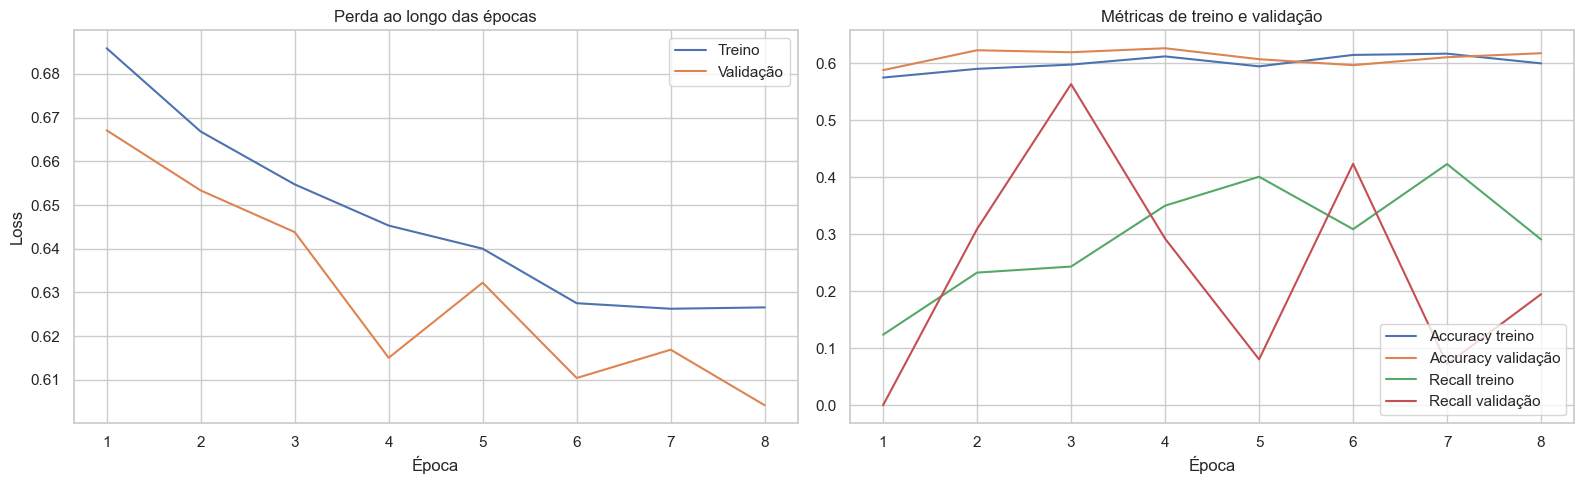

In [16]:
history_df = pd.DataFrame(history.history)
display(history_df.tail())

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Compara a evolução da perda em treino e validação ao longo das épocas.
axes[0].plot(history_df.index + 1, history_df['loss'], label='Treino')
axes[0].plot(history_df.index + 1, history_df['val_loss'], label='Validação')
axes[0].set_title('Perda ao longo das épocas')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss')
axes[0].legend()

# Exibe métricas centrais para observar a estabilidade do aprendizado.
axes[1].plot(history_df.index + 1, history_df['accuracy'], label='Accuracy treino')
axes[1].plot(history_df.index + 1, history_df['val_accuracy'], label='Accuracy validação')
axes[1].plot(history_df.index + 1, history_df['recall'], label='Recall treino')
axes[1].plot(history_df.index + 1, history_df['val_recall'], label='Recall validação')
axes[1].set_title('Métricas de treino e validação')
axes[1].set_xlabel('Época')
axes[1].legend()

plt.tight_layout()
plt.show()


A tabela final e os gráficos mostram que houve algum aprendizado ao longo do treinamento, mas de forma limitada. A `loss` caiu em relação ao início, e a `accuracy` de treino ficou próxima de `0.60`, enquanto a validação oscilou em torno de `0.60` a `0.63`.

O ponto mais sensível aparece no `recall` de validação, que variou bastante entre as épocas e terminou em `0.1949`. Isso indica que modelo teve dificuldade para recuperar os casos malignos com consistência. Esse comportamento é compatível com um modelo pequeno, com imagens reduzidas e poucas épocas, o que favorece um experimento leve, mas limita a capacidade de generalização.


## 9. Avaliação no conjunto de teste

A próxima célula aplica o modelo treinado ao conjunto de teste e resume o desempenho com `accuracy`, `auc`, `loss`, `precision` e `recall`. Essas métricas mostram como a CNN se comportou em imagens que não participaram do treinamento.


In [19]:
test_metrics = model.evaluate(test_ds, return_dict=True, verbose=0)
test_metrics_df = pd.DataFrame(
    {
        'métrica': list(test_metrics.keys()),
        'valor': list(test_metrics.values()),
    }
)

display(test_metrics_df)


,métrica,valor
0,accuracy,0.605114
1,auc,0.599147
2,loss,0.652445
3,precision,0.490000
4,recall,0.177536


No teste, o modelo obteve `accuracy = 0.6051`, `auc = 0.5991`, `precision = 0.4900` e `recall = 0.1775` para a classe positiva. Esses valores mostram que o modelo conseguiu algum nível de separação entre as classes, mas ainda com desempenho fraco para identificação dos casos malignos.

O resultado mais preocupante é o `recall`, porque ele indica que apenas uma parcela pequena dos recortes malignos foi corretamente recuperada. Em um problema como este, esse comportamento reduz bastante a utilidade prática do modelo. A `auc` próxima de `0.60` reforça a mesma leitura: a CNN apresentou capacidade discriminativa modesta, superior ao acaso, mas ainda distante do ideal.


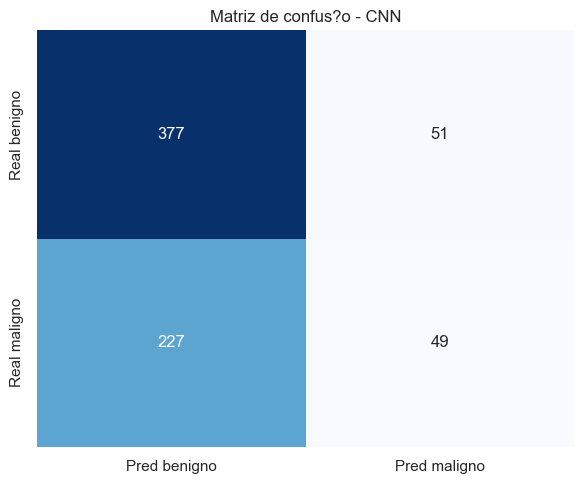

,classe,precision,recall,f1-score,support
0,Benigno,0.624172,0.880841,0.730620,428.000000
1,Maligno,0.490000,0.177536,0.260638,276.000000
2,accuracy,0.605114,0.605114,0.605114,0.605114
3,macro avg,0.557086,0.529189,0.495629,704.000000
4,weighted avg,0.571571,0.605114,0.546366,704.000000


In [18]:
y_score = model.predict(test_ds, verbose=0).ravel()
y_pred = (y_score >= 0.5).astype(int)  # Converte probabilidades em classes previstas.
y_true = test_df['label_encoded'].to_numpy()

cm = confusion_matrix(y_true, y_pred)
cm_df = pd.DataFrame(
    cm,
    index=['Real benigno', 'Real maligno'],
    columns=['Pred benigno', 'Pred maligno'],
)

report = classification_report(
    y_true,
    y_pred,
    target_names=['Benigno', 'Maligno'],
    output_dict=True,
    zero_division=0,
)
report_df = (
    pd.DataFrame(report)
    .T
    .reset_index()
    .rename(columns={'index': 'classe'})
)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax)
ax.set_title('Matriz de confus?o - CNN')
plt.tight_layout()
plt.show()

display(report_df)


A matriz de confusão e o relatório de classificação detalham melhor onde a rede acertou e onde ela falhou. Para a classe `Benigno`, o modelo alcançou `precision = 0.6242`, `recall = 0.8808` e `f1-score = 0.7306`, o que mostra um desempenho bem melhor nessa classe. Já para `Maligno`, os valores caíram para `precision = 0.4900`, `recall = 0.1775` e `f1-score = 0.2606`.

Na prática, isso significa que a CNN tendeu a reconhecer com mais facilidade os casos benignos e deixou escapar muitos recortes malignos. Esse desequilíbrio aparece de forma clara na matriz de confusão: a maior parte dos erros está concentrada justamente nos falsos negativos da classe maligna. Como esta versão do experimento foi mantida simples e compacta para permitir execução local, esse resultado deve ser entendido como uma limitação esperada da modelagem escolhida, e não como evidência de que a abordagem com CNN seja inadequada para o problema.


## 10. Conclusão

Este projeto apresentou um fluxo de classificação de recortes mamográficos com uma CNN treinada do zero, utilizando uma base já organizada em classes e recortes prontos para leitura. A estrutura do experimento ficou adequada para execução local e permitiu demonstrar, de forma clara, as etapas centrais de preparação, treinamento e avaliação de uma rede neural convolucional.

Os resultados, porém, foram modestos. Embora a rede tenha alcançado cerca de `60%` de acurácia, o desempenho na classe maligna foi fraco, especialmente pelo `recall` de `0.1775`, o que mostra que muitos casos malignos não foram identificados corretamente. Esse comportamento é compatível com a simplificação adotada nesta versão: imagens reduzidas para `96x96`, arquitetura compacta e apenas `8` épocas.

Uma versão mais forte poderia explorar imagens com maior resolução, mais épocas de treinamento, ajustes adicionais de arquitetura e estratégias mais cuidadosas para melhorar a recuperação da classe maligna. Ainda assim, este projeto cumpre o papel de mostrar como uma CNN pode ser aplicada ao problema e como seus resultados devem ser analisados de forma crítica.
